In [75]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import csv
from scipy.interpolate import RectBivariateSpline
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [76]:
data_path = 'Potential-PressureDistributionData.csv'

with open(data_path, 'r', encoding='utf-8') as file:
    reader = csv.reader(file, delimiter=';')
    og_columns = next(reader)

data = pd.read_csv(data_path, sep=';', skiprows=1, header=None)
data.columns = og_columns

In [77]:
filtered_cond = data[(data['Re'] == 1000000) & (data['AoA'] == 13)]

airfoil = pd.read_csv('utils/NACA23015.dat', sep=',', names=['x', 'y'])
# array com 201 linhas, passando do TE ao TE em escala real
x_sectional = (airfoil['x'].values)*0.2165
# array com 201 linhas com a espessura do aerofólio em cada coordenada x
z_sectional = (airfoil['y'].values)*0.15

# array de 80 linhas
y_orig = filtered_cond['y'].values
# array de 80 linhas e 201 colunas
cp_data_orig = filtered_cond.iloc[:, 4:].to_numpy()

In [78]:
sort_idx = np.argsort(y_orig)
y_orig_sorted = y_orig[sort_idx]
cp_data_sorted = cp_data_orig[sort_idx, :]

idx_real = np.linspace(0, 1, cp_data_orig.shape[1])
idx_target = np.linspace(0, 1, len(x_sectional))

num_y_points = 120
y_target = np.linspace(y_orig_sorted.min(), 0.766, 120)

f_interp_2d = RectBivariateSpline(y_orig_sorted, idx_real, cp_data_sorted)
cp_data = f_interp_2d(y_target, idx_target).T

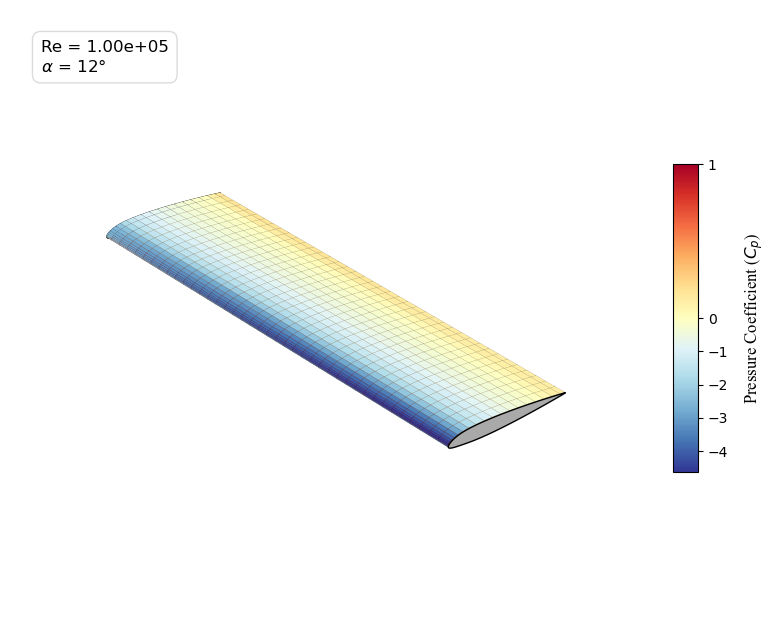

In [86]:
X = np.tile(x_sectional, (len(y_target), 1)).T
Y = np.tile(y_target, (len(x_sectional), 1))
Z = np.tile(z_sectional, (len(y_target), 1)).T

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([0.2165, 0.766, 0.022])

texto_info = f"Re = {100000:.2e}\n$\\alpha$ = {12}°"
ax.text2D(0.05, 0.90, texto_info, transform=ax.transAxes, 
          fontsize=12, color='black',
          bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray', boxstyle='round,pad=0.5'))

ax.set_axis_off()

norm = TwoSlopeNorm(vmin = cp_data.min(), vcenter=0, vmax=1)
cmap = cm.RdYlBu_r
face_colors = cmap(norm(cp_data))

ax.plot_surface(X, Y, Z, facecolors=face_colors, edgecolor='k', linewidth=0.05, shade=False)

v_root = np.array([X[:,0], Y[:, 0], Z[:, 0]]).T
ax.add_collection3d(Poly3DCollection([v_root], facecolors='darkgray', edgecolors='black', alpha=1.0))
v_tip = np.array([X[:,-1], Y[:, -1], Z[:, -1]]).T
ax.add_collection3d(Poly3DCollection([v_tip], facecolors='darkgray', edgecolors='black', alpha=1.0))

m = (cm.ScalarMappable(cmap=cmap, norm=norm))
m.set_array([])
cbar = plt.colorbar(m, ax=ax, shrink=0.5, aspect=12)
cbar.set_label('Pressure Coefficient ($C_p$)', labelpad=10, fontname='Times New Roman', fontsize=12)

ax.view_init(elev=30, azim=-130)
plt.show()